In [14]:
import numpy as np
print(np.__version__)

1.26.4


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
 

In [16]:
df=pd.read_csv('Bank_additional_full.csv',sep=';', )

In [17]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
 
print('All libraries imported successfully.')

All libraries imported successfully.


In [23]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.10,94.77,-50.80,1.03,4963.60,yes


In [19]:
# Rename target from 'y' to 'subscribed' — clearer for the report
df.rename(columns={'y': 'subscribed'}, inplace=True)
 
print(f'Dataset loaded successfully.')
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'\nColumn names:')
print(df.columns.tolist())

Dataset loaded successfully.
Rows    : 41,188
Columns : 21

Column names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'subscribed']


In [20]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [21]:
df.describe(include='object')

C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,subscribed
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


In [24]:
# Loop through every column and print the count of 'unknown' values
for col in df.columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f'{col}: {count} unknowns')

job: 330 unknowns
marital: 80 unknowns
education: 1731 unknowns
default: 8597 unknowns
housing: 990 unknowns
loan: 990 unknowns


In [25]:
# Check just one column
print(df['education'].value_counts())

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64


In [26]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
if 'subscribed' in cat_cols:
    cat_cols.remove('subscribed')
 
unknown_summary = {}
for col in cat_cols:
    count = (df[col] == 'unknown').sum()
    pct   = count / len(df) * 100
    unknown_summary[col] = {'Unknown Count': count, 'Unknown (%)': round(pct, 2)}
 
unknown_df = pd.DataFrame(unknown_summary).T
unknown_df = unknown_df[unknown_df['Unknown Count'] > 0]
 
if len(unknown_df) > 0:
    print('Columns containing "unknown" values:')
    print(unknown_df.to_string())
    print(f'\nTotal unknown entries: {unknown_df["Unknown Count"].sum():,.0f}')
else:
    print('No unknown values found.')

Columns containing "unknown" values:
           Unknown Count  Unknown (%)
job               330.00         0.80
marital            80.00         0.19
education        1731.00         4.20
default          8597.00        20.87
housing           990.00         2.40
loan              990.00         2.40

Total unknown entries: 12,718


C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\373831003.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [27]:
never_contacted = (df['pdays'] == 999).sum()
was_contacted   = (df['pdays'] != 999).sum()
 
print(f'pdays = 999 (never contacted)  : {never_contacted:,}  ({never_contacted/len(df)*100:.1f}%)')
print(f'pdays < 999 (was contacted)    : {was_contacted:,}  ({was_contacted/len(df)*100:.1f}%)')
print()
print("Strategy: Create binary feature 'was_previously_contacted' (0 or 1).")
print("The raw pdays column will be dropped during preprocessing.")

pdays = 999 (never contacted)  : 39,673  (96.3%)
pdays < 999 (was contacted)    : 1,515  (3.7%)

Strategy: Create binary feature 'was_previously_contacted' (0 or 1).
The raw pdays column will be dropped during preprocessing.


In [28]:
duplicates_found = df.duplicated().sum()
print(f'Duplicate rows found: {duplicates_found}')
 
df.drop_duplicates(keep='first', ignore_index=True, inplace=True)
print(f'Duplicates removed. Dataset now has {len(df):,} rows.')
 

Duplicate rows found: 12
Duplicates removed. Dataset now has 41,176 rows.


In [29]:
# Create three lists reused throughout the entire project
# Defining them once here keeps all subsequent code clean
 
numerical_cols   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
 
if 'subscribed' in categorical_cols:
    categorical_cols.remove('subscribed')
 
print(f'Numerical columns ({len(numerical_cols)}):')
for col in numerical_cols:
    print(f'  {col}')
 
print(f'\nCategorical columns ({len(categorical_cols)}):')
for col in categorical_cols:
    print(f'  {col}')
 
print(f'\nTarget column: subscribed (binary — yes / no)')

Numerical columns (10):
  age
  duration
  campaign
  pdays
  previous
  emp.var.rate
  cons.price.idx
  cons.conf.idx
  euribor3m
  nr.employed

Categorical columns (10):
  job
  marital
  education
  default
  housing
  loan
  contact
  month
  day_of_week
  poutcome

Target column: subscribed (binary — yes / no)


C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\2288460244.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


Target Variable — Class Distribution
            Count  Percentage (%)
subscribed                       
no          36537           88.73
yes          4639           11.27


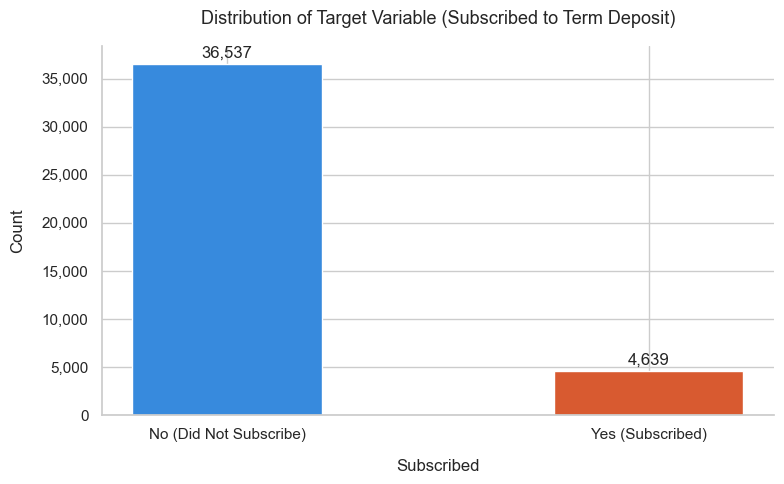


Class imbalance: 88.7% no  vs  11.3% yes
This will be addressed using SMOTE inside the pipeline (Section 3.3.7).


In [30]:
# Most important early finding — confirms the class imbalance
# A naive model always predicting 'no' would be 88.7% accurate but useless
# This motivates the use of SMOTE in preprocessing
 
counts = df['subscribed'].value_counts()
pcts   = df['subscribed'].value_counts(normalize=True) * 100
 
summary = pd.DataFrame({
    'Count'          : counts,
    'Percentage (%)' : pcts.round(2)
})
print('Target Variable — Class Distribution')
print(summary)
 
fig, ax = plt.subplots(figsize=(8, 5))
 
colours = ['#378ADD', '#D85A30']
bars = ax.bar(
    ['No (Did Not Subscribe)', 'Yes (Subscribed)'],
    counts.values,
    color=colours,
    width=0.45,
    edgecolor='white'
)
 
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f'{bar.get_height():,}',
        ha='center', va='bottom', fontsize=12, fontweight='medium'
    )
 
ax.set_title('Distribution of Target Variable (Subscribed to Term Deposit)',
             pad=16, fontsize=13)
ax.set_xlabel('Subscribed', labelpad=12)
ax.set_ylabel('Count', labelpad=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine(top=True, right=True)
 
plt.tight_layout()
plt.savefig('fig_3_2_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
 
print(f"\nClass imbalance: {pcts['no']:.1f}% no  vs  {pcts['yes']:.1f}% yes")
print('This will be addressed using SMOTE inside the pipeline (Section 3.3.7).')

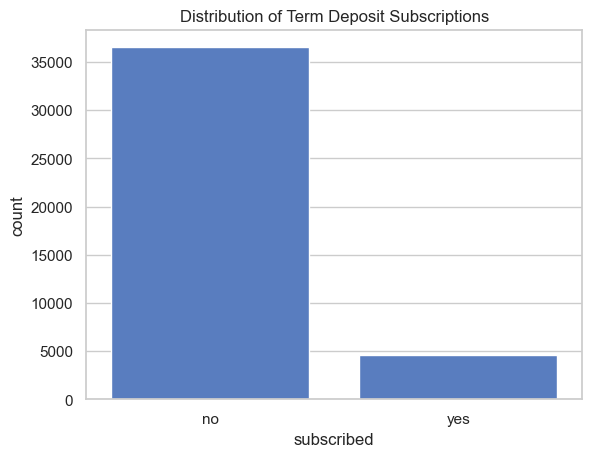

In [33]:
# Target variable bar plot
sns.countplot(data=df, x='subscribed')
plt.title('Distribution of Term Deposit Subscriptions')
plt.show()

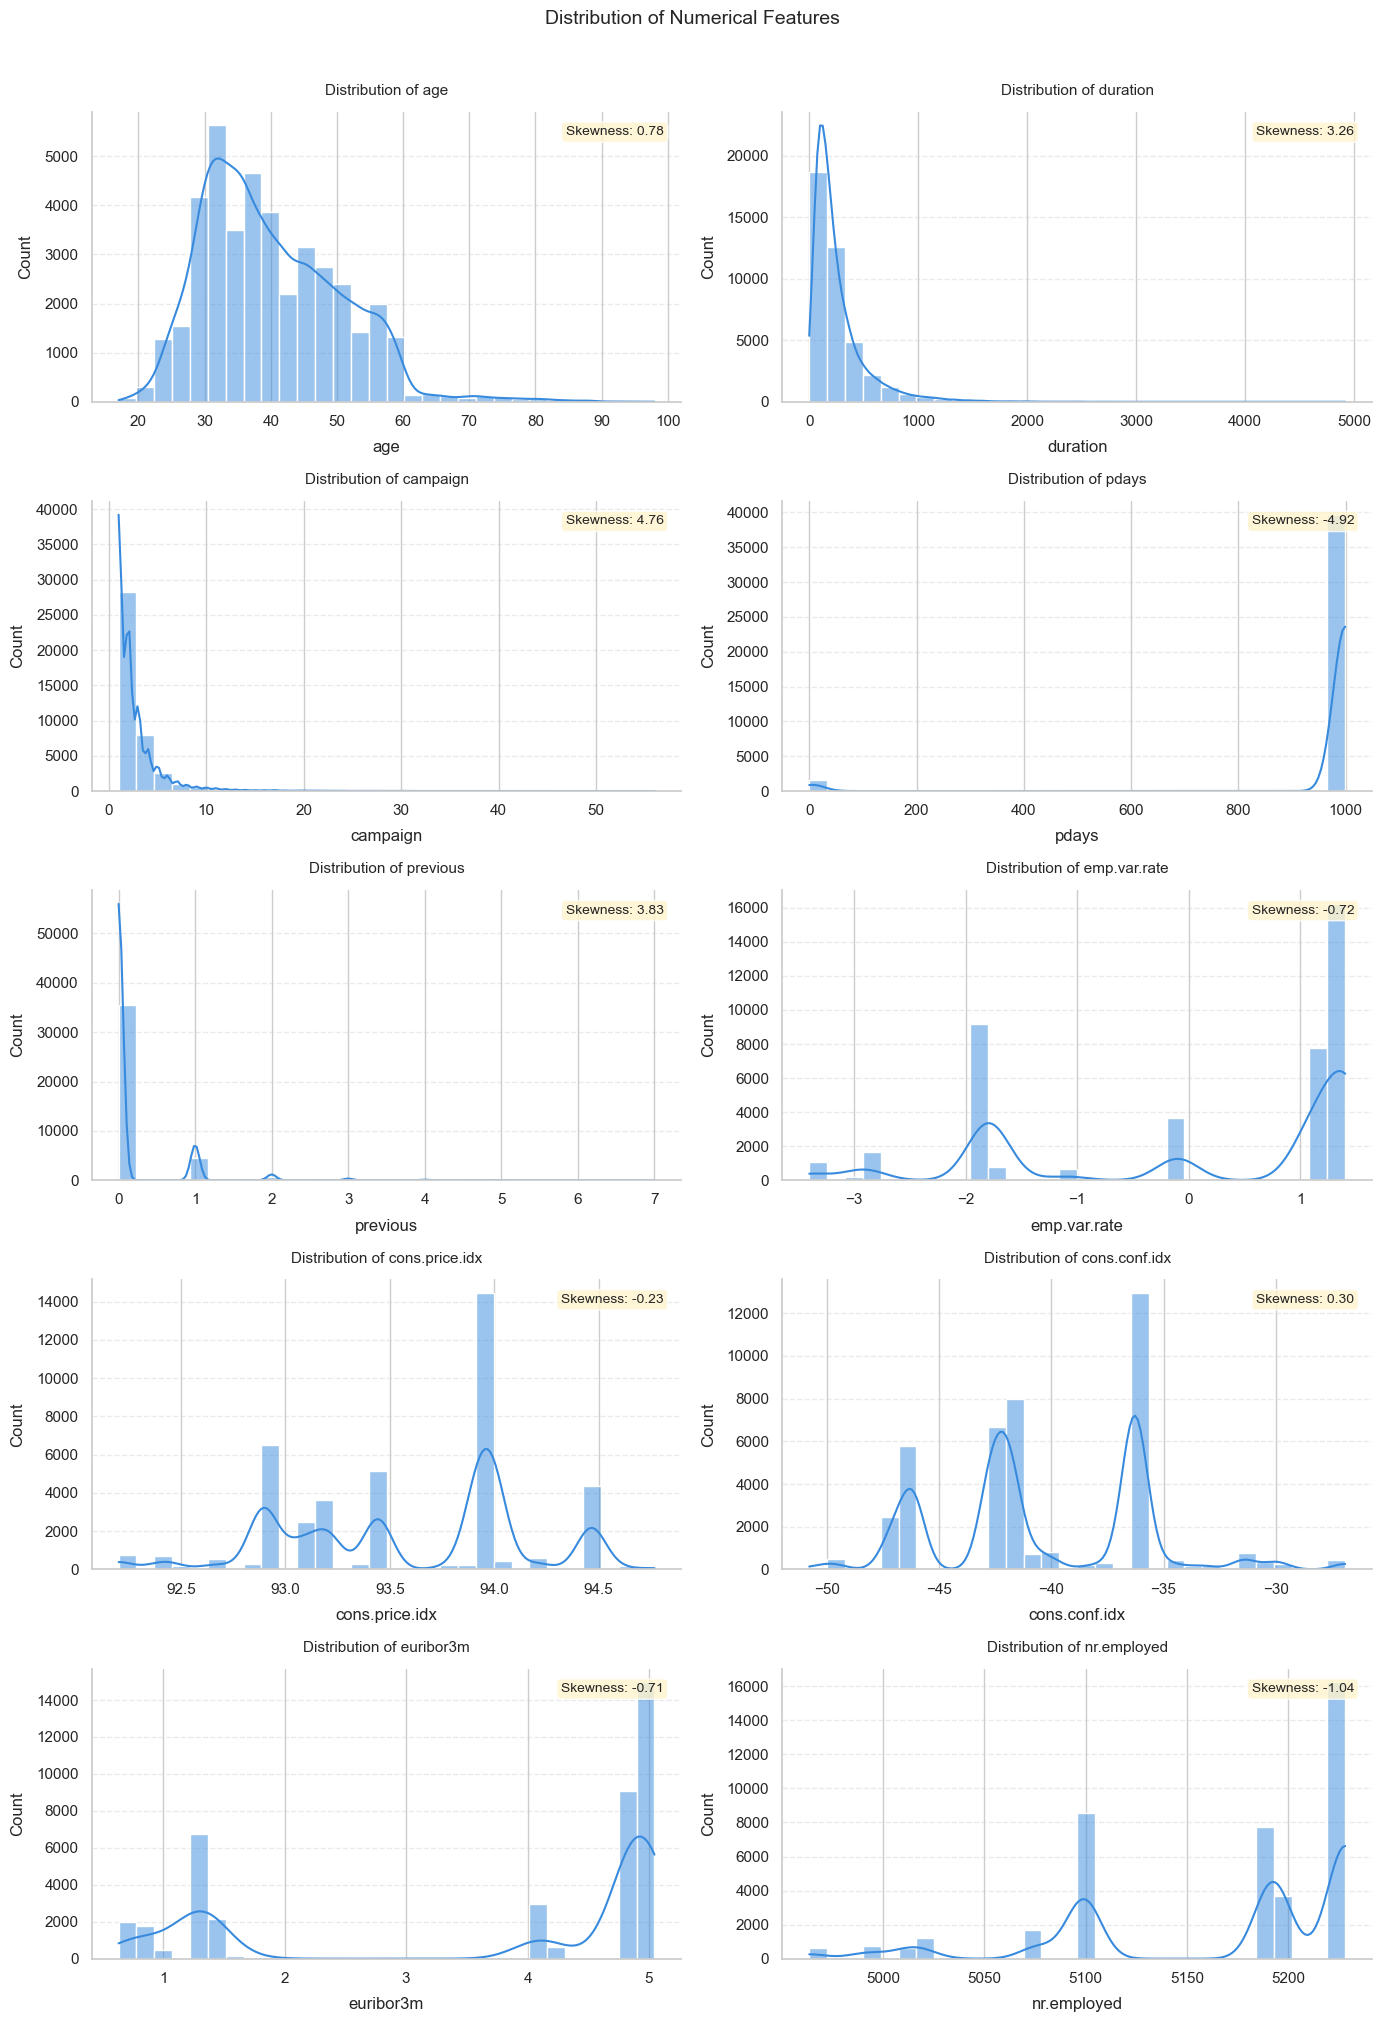

C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\3107420722.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax,
C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\3107420722.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\3107420722.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax,
C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\3107420722.py:51: FutureWarning: 

Passing `palette` without assigni

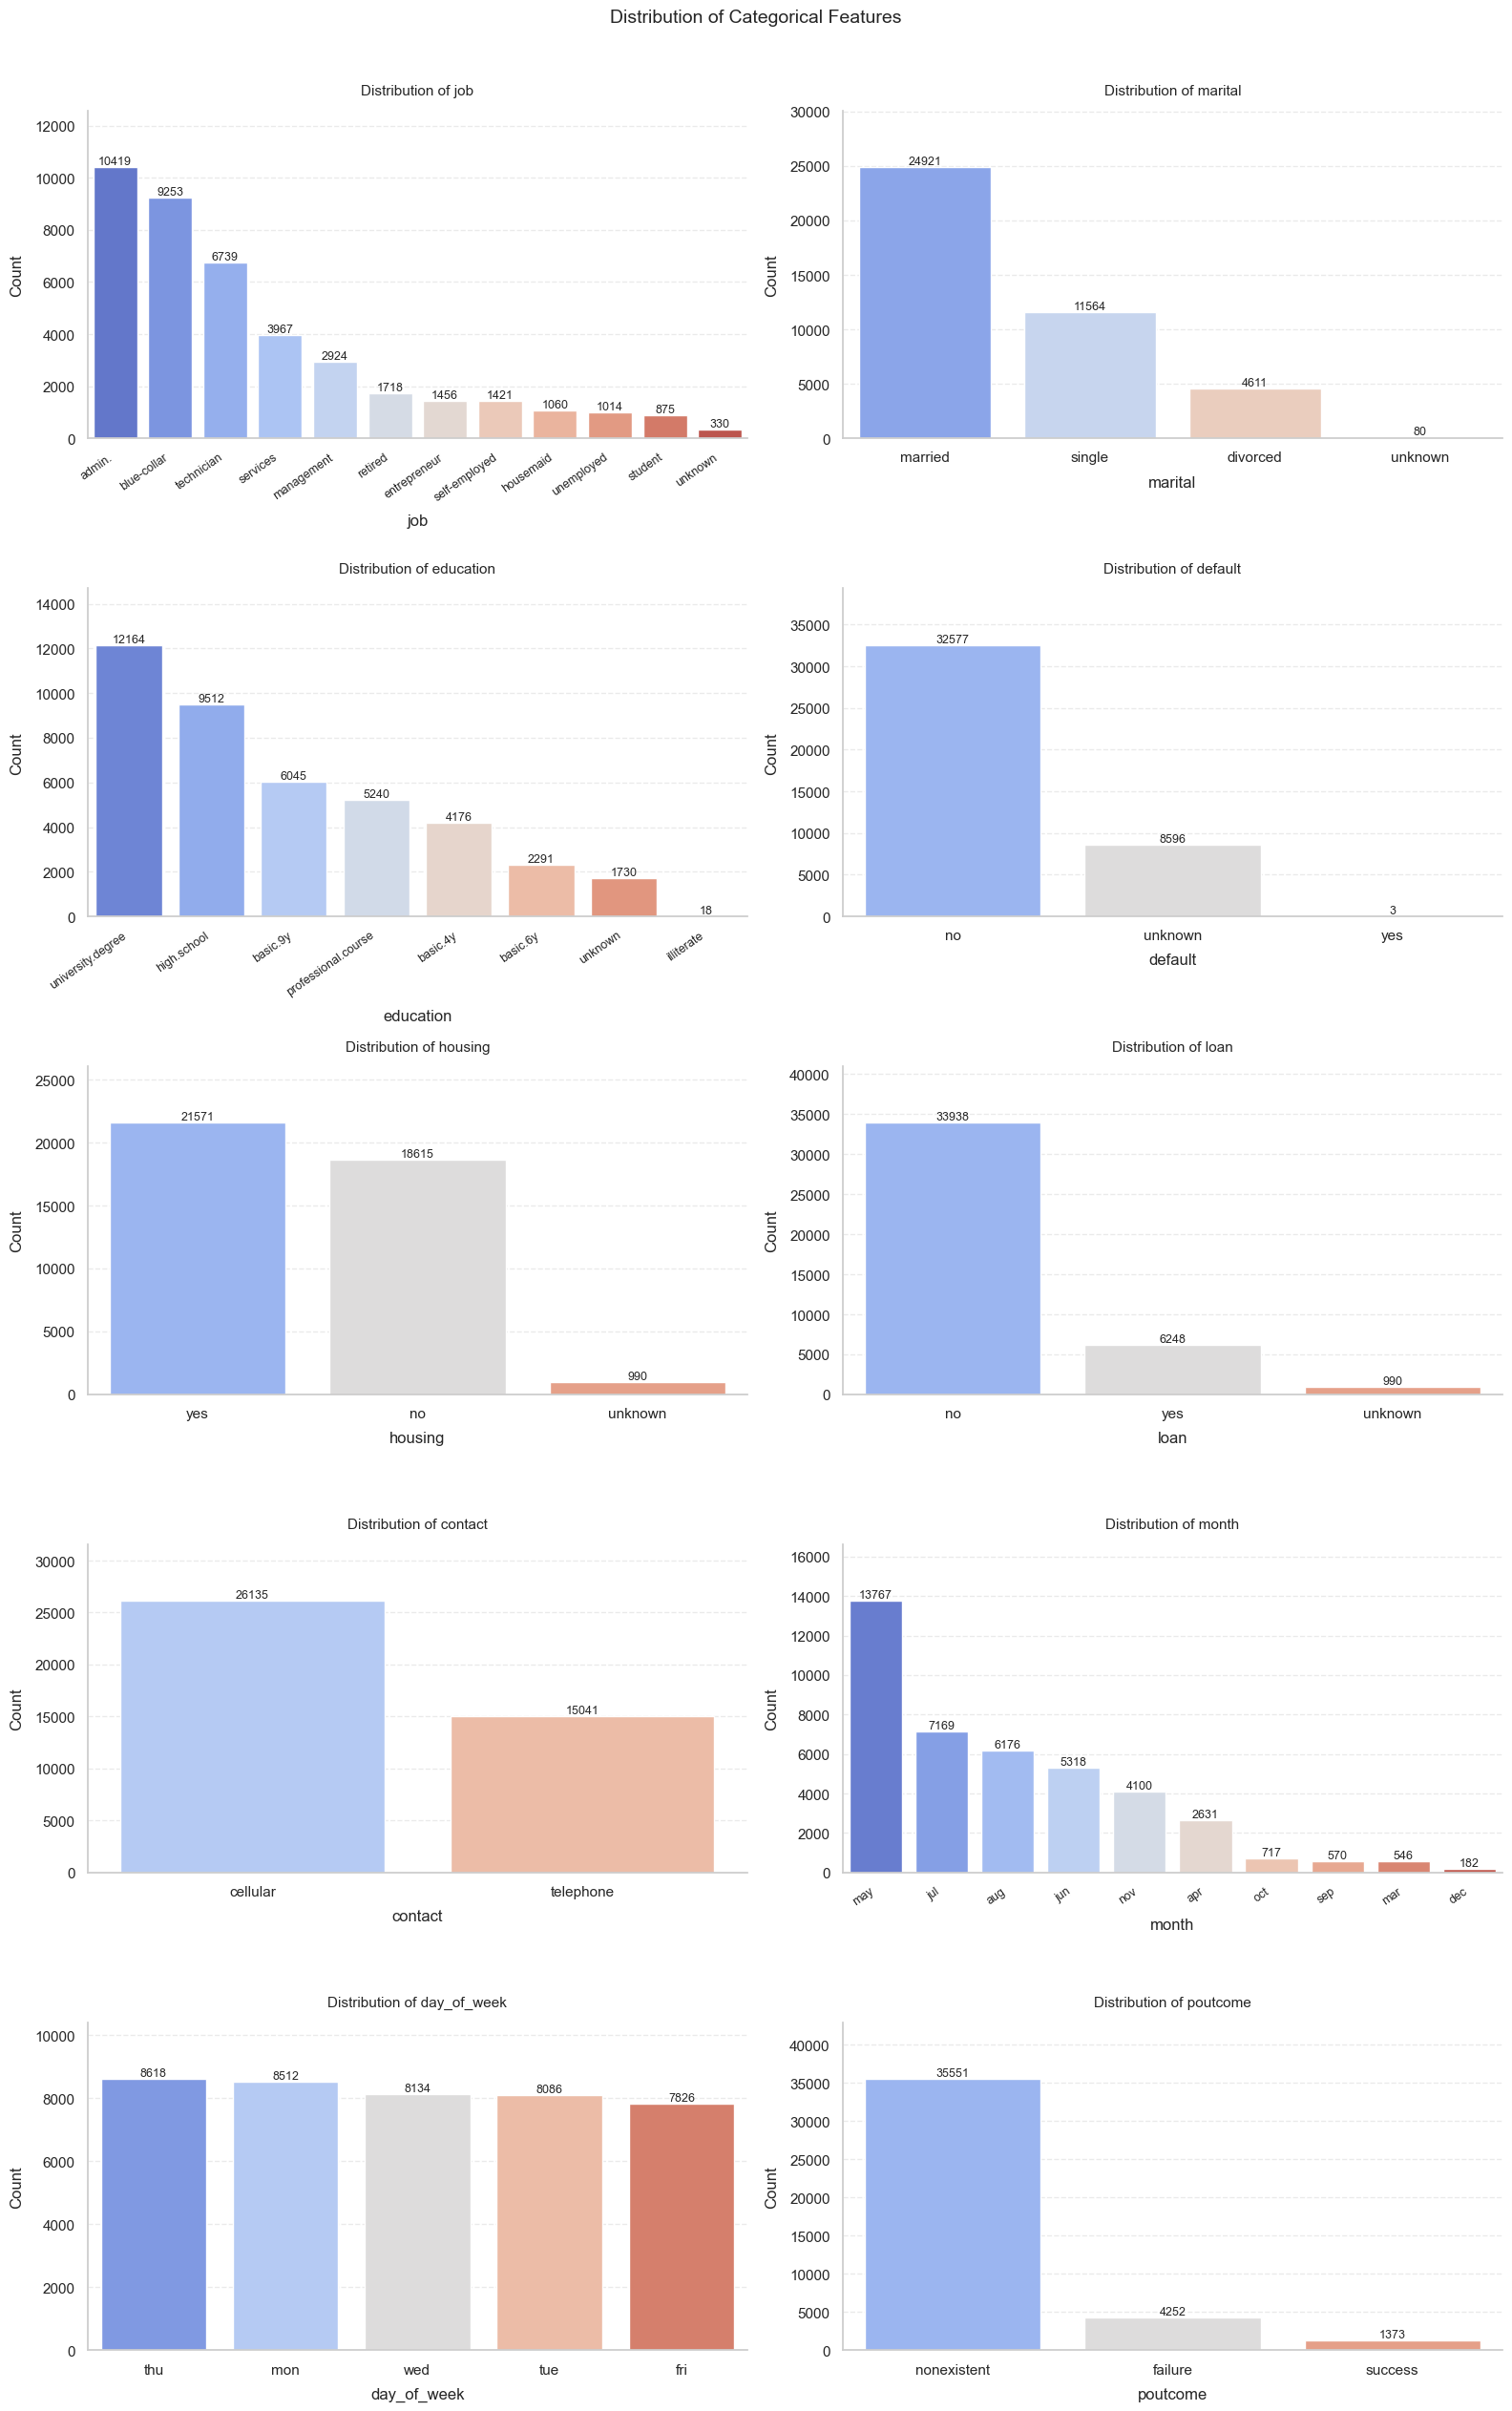

In [34]:
# Histogram + KDE for every numerical column
# Skewness annotated on each plot — values above 1.0 indicate skewed distributions
 
n_cols = 2
n_rows = (len(numerical_cols) + 1) // n_cols
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()
 
for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color='#378ADD')
 
    skew = df[col].skew()
    ax.text(0.97, 0.95,
            f'Skewness: {skew:.2f}',
            transform=ax.transAxes,
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3CD', alpha=0.8),
            fontsize=10)
 
    ax.set_title(f'Distribution of {col}', pad=12, fontsize=11)
    ax.set_xlabel(col, labelpad=8)
    ax.set_ylabel('Count', labelpad=8)
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle('Distribution of Numerical Features', fontsize=14, y=1.01, fontweight='medium')
plt.tight_layout()
plt.savefig('fig_numerical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
 
 


C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\411031218.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax,
C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\411031218.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\411031218.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax,
C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\411031218.py:15: FutureWarning: 

Passing `palette` without assigning `

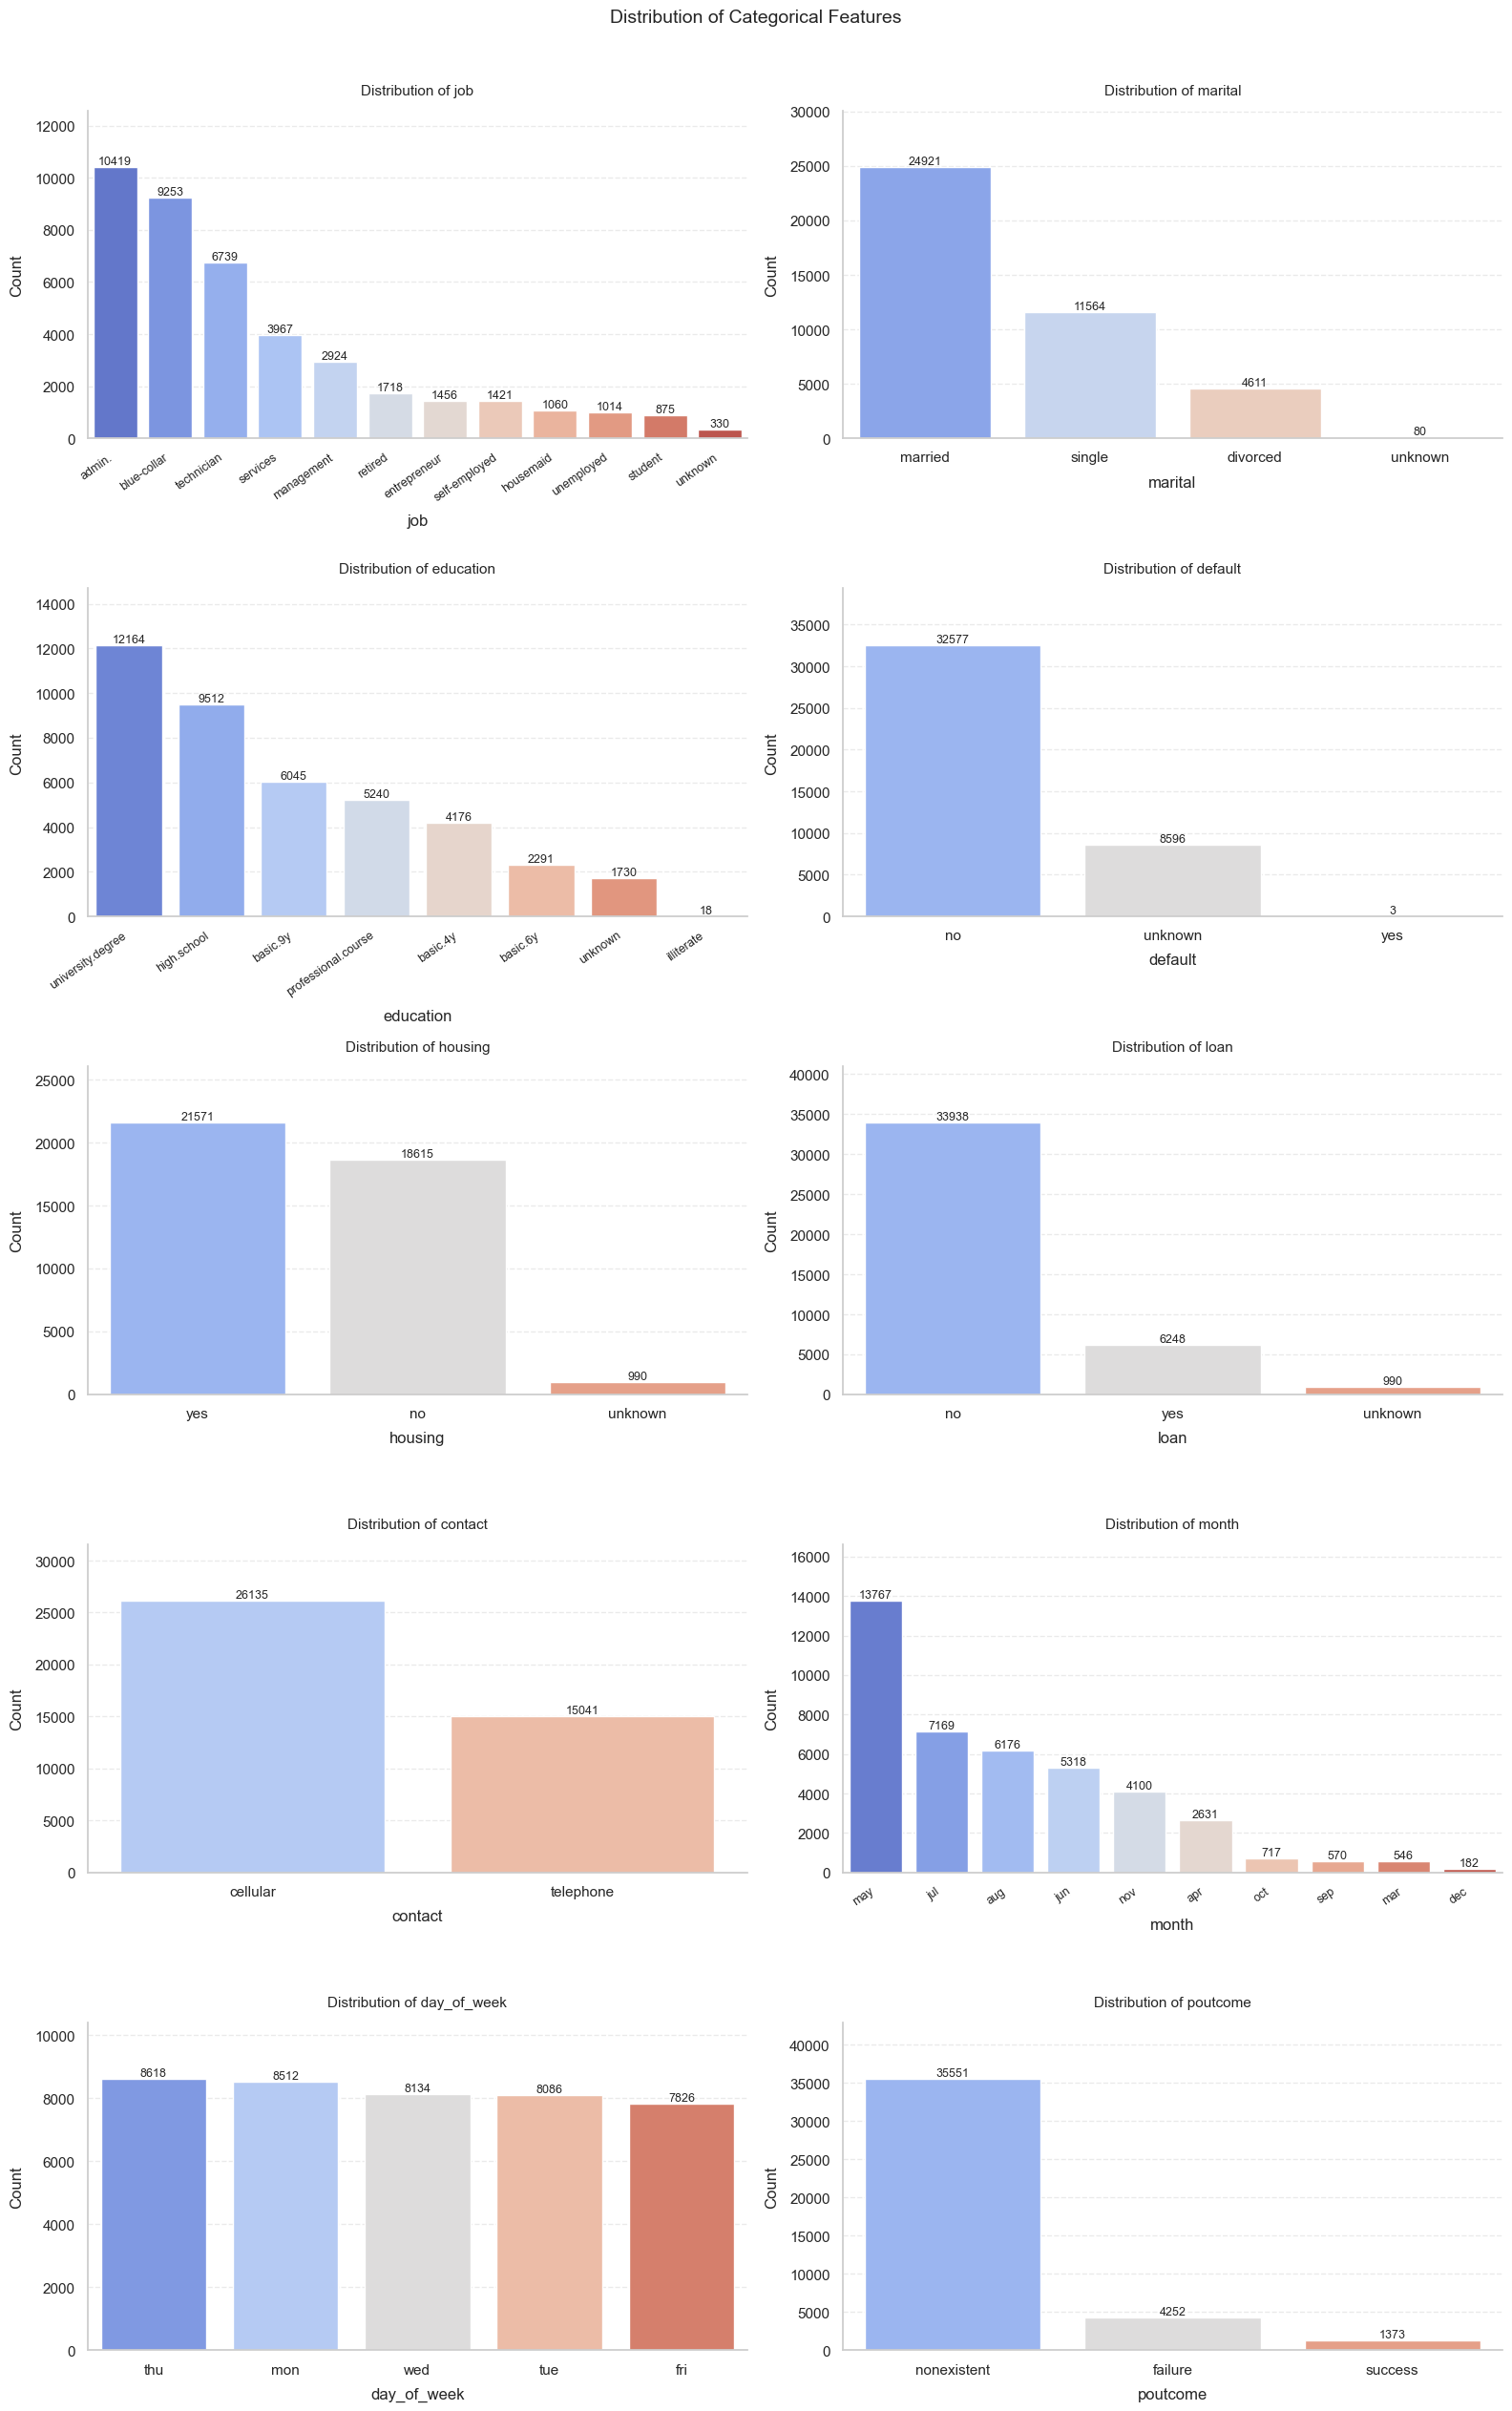

In [36]:
# ── CELL 13: Distribution of Categorical Features ────────────────────────────
# Count plots for every categorical column
# Makes 'unknown' values visually apparent — motivates preprocessing decisions
 
n_cols = 2
n_rows = (len(categorical_cols) + 1) // n_cols
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()
 
for i, col in enumerate(categorical_cols):
    ax = axes[i]
    order = df[col].value_counts().index
 
    sns.countplot(data=df, x=col, order=order, ax=ax,
                  palette='coolwarm', edgecolor='white')
 
    if df[col].nunique() > 5:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
 
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)
 
    ax.set_title(f'Distribution of {col}', pad=12, fontsize=11)
    ax.set_xlabel(col, labelpad=8)
    ax.set_ylabel('Count', labelpad=8)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle('Distribution of Categorical Features', fontsize=14, y=1.01, fontweight='medium')
plt.tight_layout()
plt.savefig('fig_categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

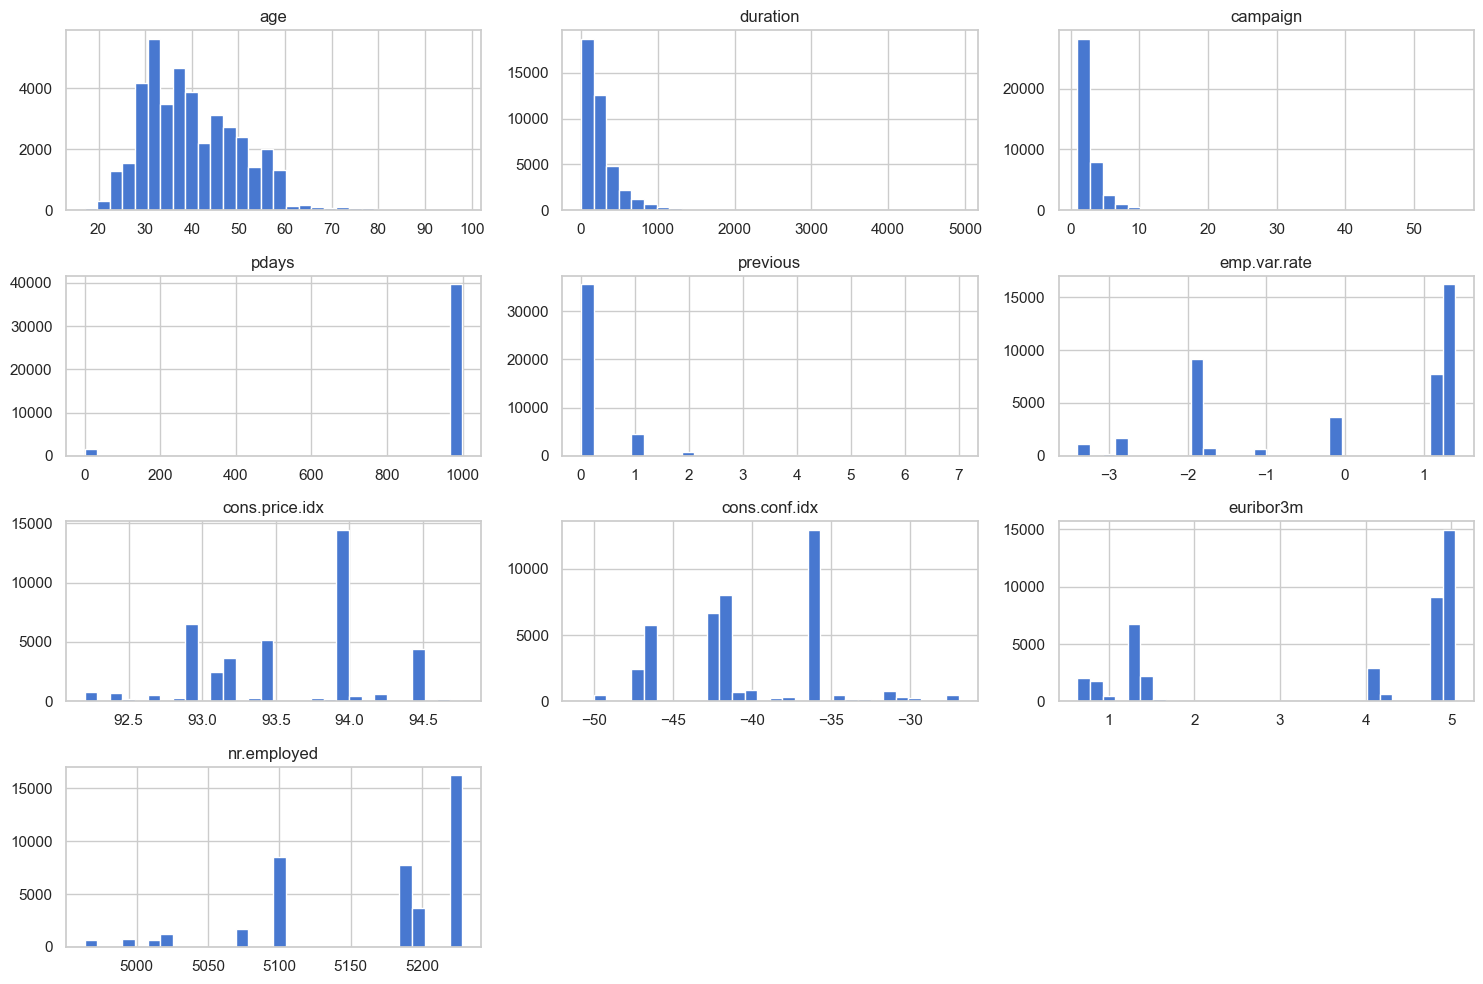

In [35]:
# Numeric feature distributions
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

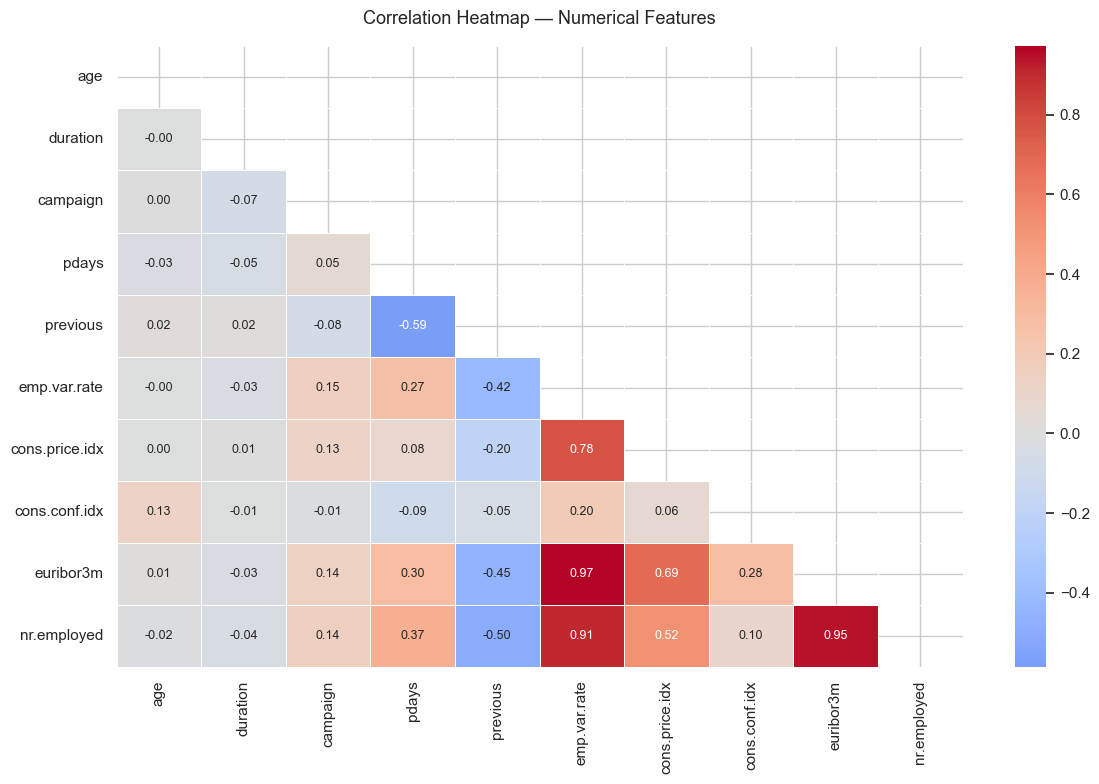

In [41]:
# Strong correlations (|r| > 0.70) indicate multicollinearity
# Upper triangle masked to avoid repeating values
# Discussed in Section 3.2.4 of the report
 
fig, ax = plt.subplots(figsize=(12, 8))
 
corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
 
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
 
ax.set_title('Correlation Heatmap — Numerical Features', pad=16, fontsize=13)
plt.tight_layout()
plt.savefig('fig_3_6_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
 
#"""print('Strong correlations (|r| > 0.70):')
#strong = []
#for i in range(len(corr_matrix.columns)):
 #   for j in range(i):
  #      r = corr_matrix.iloc[i, j]
   #     if abs(r) > 0.70:
    #        strong.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))"""
 
#"""if strong:
 #   for pair in strong:
  #      print(f'  {pair[0]}  <-->  {pair[1]}  :  r = {pair[2]}')
#else:
 #   print('  No strongly correlated pairs found.')"""
 

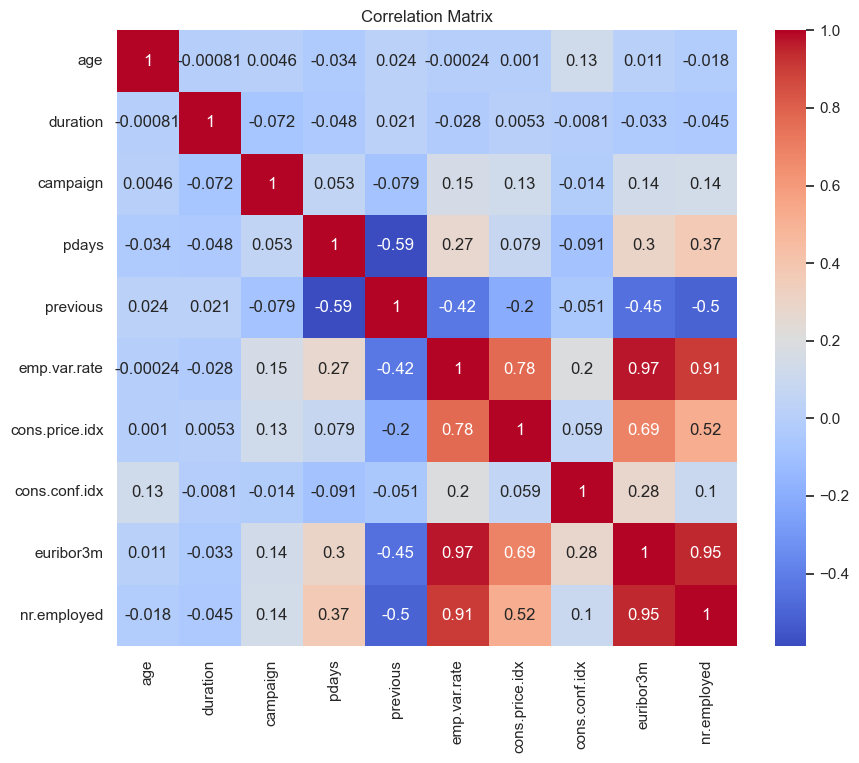

In [38]:
# Correlation heatmap (numeric features only)
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\3215774103.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=col, y='subscription_rate', ax=ax,
C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\3215774103.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\3215774103.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate, x=col, y='subscription_rate', ax=ax,
C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\3215774103.py:22: FutureWarning: 

Passing `pale

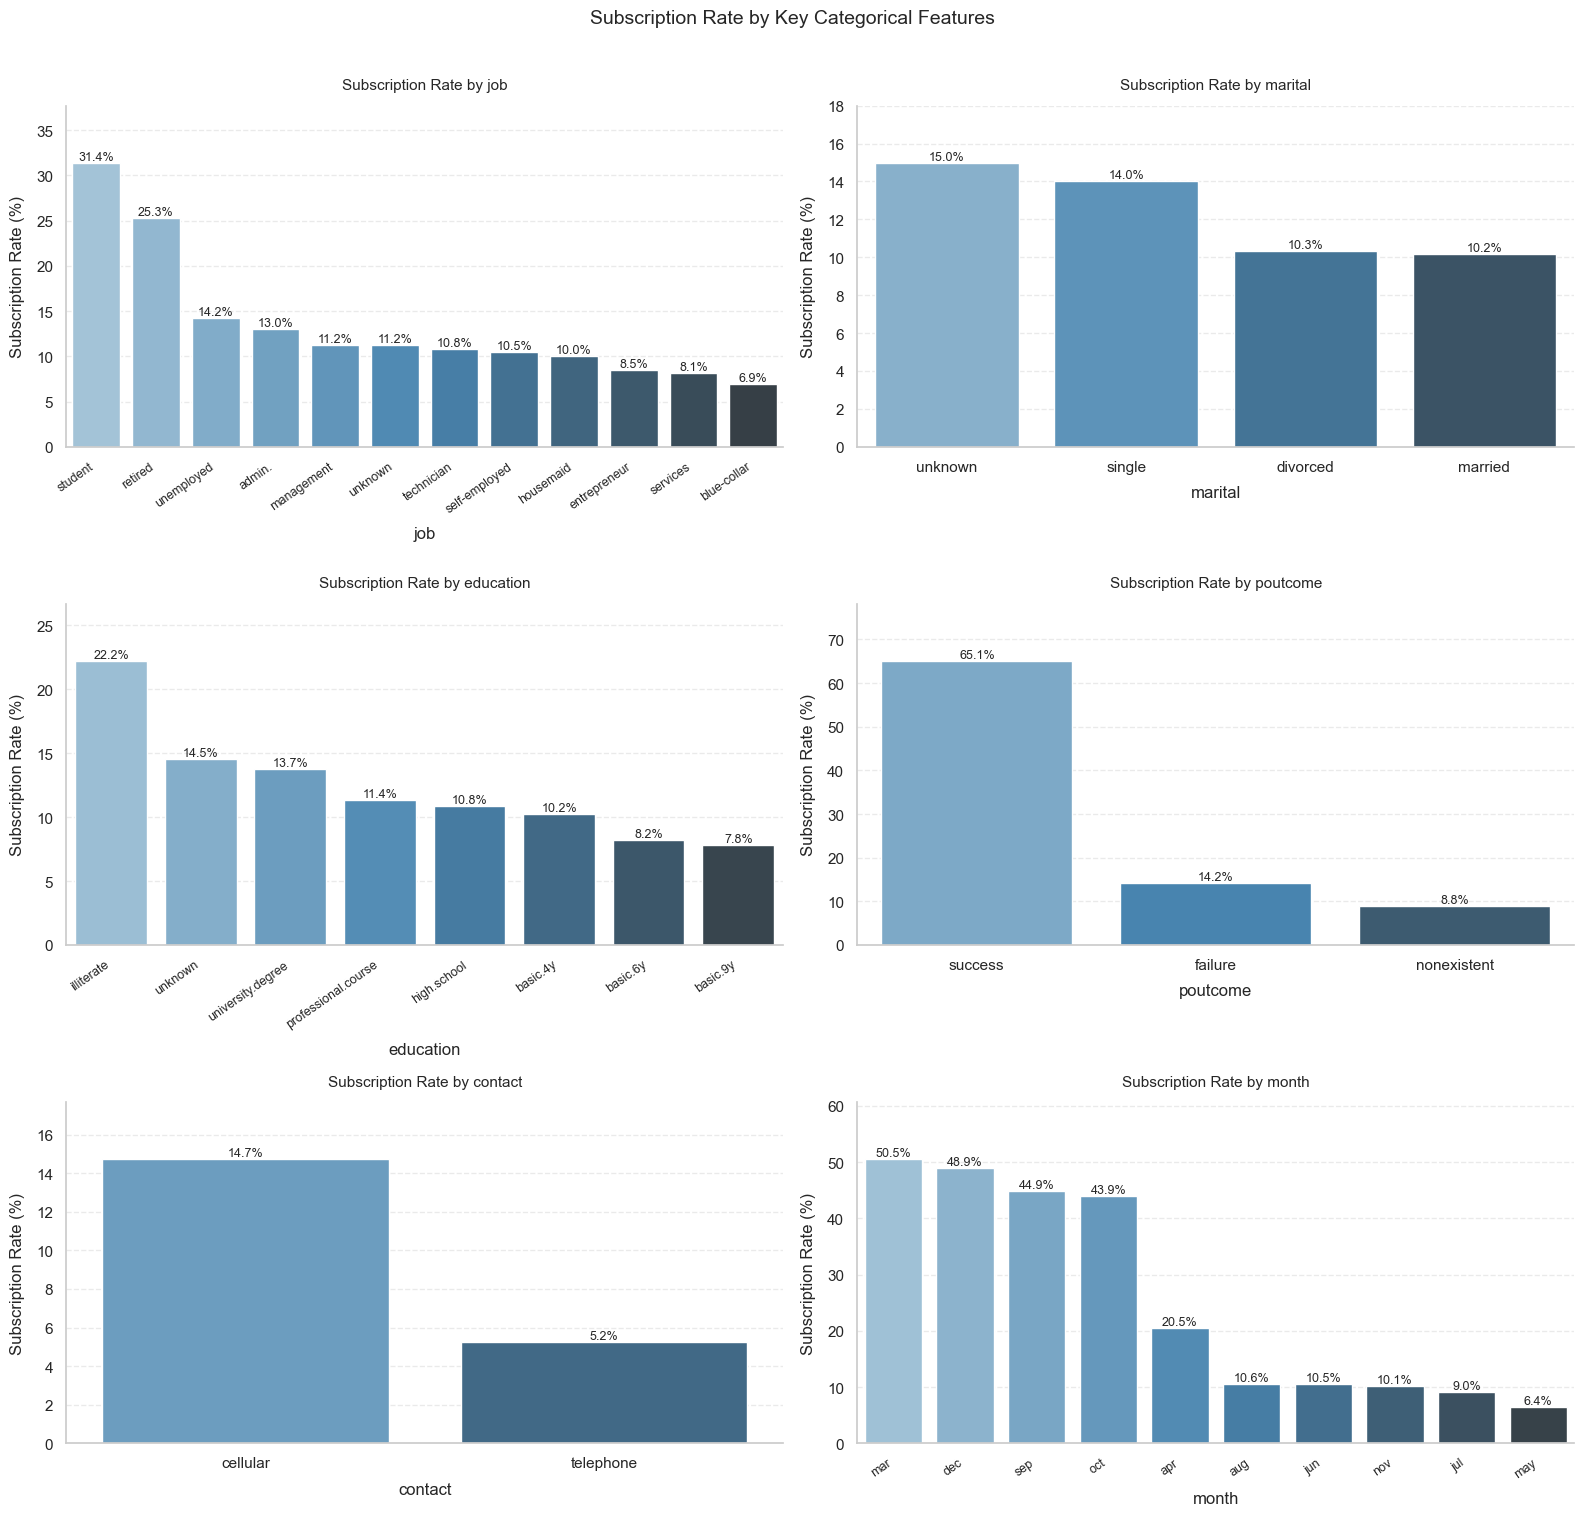

In [42]:
# Which categories are most associated with a 'yes' subscription?
# Feeds directly into Section 5.2 (Feature Importance) in the Discussion
 
key_cats = ['job', 'marital', 'education', 'poutcome', 'contact', 'month']
 
n_cols = 2
n_rows = (len(key_cats) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()
 
for i, col in enumerate(key_cats):
    ax = axes[i]
 
    rate = (
        df.groupby(col)['subscribed']
        .apply(lambda x: (x == 'yes').mean() * 100)
        .sort_values(ascending=False)
        .reset_index()
    )
    rate.columns = [col, 'subscription_rate']
 
    sns.barplot(data=rate, x=col, y='subscription_rate', ax=ax,
                palette='Blues_d', edgecolor='white')
 
    if df[col].nunique() > 4:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
 
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)
 
    ax.set_title(f'Subscription Rate by {col}', pad=12, fontsize=11)
    ax.set_xlabel(col, labelpad=8)
    ax.set_ylabel('Subscription Rate (%)', labelpad=8)
    ax.set_ylim(0, rate['subscription_rate'].max() * 1.2)
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
 
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
 
plt.suptitle('Subscription Rate by Key Categorical Features',
             fontsize=14, y=1.01, fontweight='medium')
plt.tight_layout()
plt.savefig('fig_subscription_rate_by_category.png', dpi=300, bbox_inches='tight')
plt.show()
 

In [43]:
# Values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR are classified as outliers
# Robust to non-normal distributions — same method used by Adedayo (2026)
# This table feeds into Table 3.3 of the report
 
outlier_summary = {}
 
for col in numerical_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = count / len(df) * 100
    outlier_summary[col] = {
        'Lower Bound'   : round(lower, 2),
        'Upper Bound'   : round(upper, 2),
        'Outlier Count' : count,
        'Outlier (%)'   : round(pct, 2)
    }
 
outlier_df = pd.DataFrame(outlier_summary).T
outlier_df = outlier_df[outlier_df['Outlier Count'] > 0]
 
print('Outlier Detection Summary (IQR Method) — Table 3.3')
print(outlier_df.to_string())
print(f'\nTotal outlier entries: {outlier_df["Outlier Count"].sum():,.0f}')
print('\nThese will be removed during preprocessing (Section 3.3.3).')
 

Outlier Detection Summary (IQR Method) — Table 3.3
               Lower Bound  Upper Bound  Outlier Count  Outlier (%)
age                   9.50        69.50         468.00         1.14
duration           -223.50       644.50        2963.00         7.20
campaign             -2.00         6.00        2406.00         5.84
pdays               999.00       999.00        1515.00         3.68
previous              0.00         0.00        5625.00        13.66
cons.conf.idx       -52.15       -26.95         446.00         1.08

Total outlier entries: 13,423

These will be removed during preprocessing (Section 3.3.3).


In [44]:
# Complete summary before moving to preprocessing
# These exact numbers go into Table 3.1 of the report
 
no_count  = (df['subscribed'] == 'no').sum()
yes_count = (df['subscribed'] == 'yes').sum()
 
print('=' * 58)
print('  DATASET STATE SUMMARY — END OF PART 1')
print('=' * 58)
print(f'  Total records (before preprocessing) : {len(df):,}')
print(f'  Total features (excl. target)        : {len(df.columns) - 1}')
print(f'  Numerical features                   : {len(numerical_cols)}')
print(f'  Categorical features                 : {len(categorical_cols)}')
print(f'  Target variable                      : subscribed (yes / no)')
print(f'  NaN missing values                   : {df.isnull().sum().sum()}')
print(f'  Unknown values present in            : 5 categorical columns')
print(f'  Duplicates removed                   : 12')
print(f'  pdays = 999 (never contacted)        : 39,673 rows')
print(f'  Class split — no / yes               : {no_count:,} / {yes_count:,}')
print(f'  Class split — % no / % yes           : {no_count/len(df)*100:.1f}% / {yes_count/len(df)*100:.1f}%')
print('=' * 58)
print()
print('Part 1 complete.')
print('Proceed to Part 2 — Preprocessing & Feature Engineering.')

  DATASET STATE SUMMARY — END OF PART 1
  Total records (before preprocessing) : 41,176
  Total features (excl. target)        : 20
  Numerical features                   : 10
  Categorical features                 : 10
  Target variable                      : subscribed (yes / no)
  NaN missing values                   : 0
  Unknown values present in            : 5 categorical columns
  Duplicates removed                   : 12
  pdays = 999 (never contacted)        : 39,673 rows
  Class split — no / yes               : 36,537 / 4,639
  Class split — % no / % yes           : 88.7% / 11.3%

Part 1 complete.
Proceed to Part 2 — Preprocessing & Feature Engineering.


In [45]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].unique()[:5]} ... ({df[col].nunique()} unique)")

job: <ArrowStringArray>
['housemaid', 'services', 'admin.', 'blue-collar', 'technician']
Length: 5, dtype: str ... (12 unique)
marital: <ArrowStringArray>
['married', 'single', 'divorced', 'unknown']
Length: 4, dtype: str ... (4 unique)
education: <ArrowStringArray>
['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course']
Length: 5, dtype: str ... (8 unique)
default: <ArrowStringArray>
['no', 'unknown', 'yes']
Length: 3, dtype: str ... (3 unique)
housing: <ArrowStringArray>
['no', 'yes', 'unknown']
Length: 3, dtype: str ... (3 unique)
loan: <ArrowStringArray>
['no', 'yes', 'unknown']
Length: 3, dtype: str ... (3 unique)
contact: <ArrowStringArray>
['telephone', 'cellular']
Length: 2, dtype: str ... (2 unique)
month: <ArrowStringArray>
['may', 'jun', 'jul', 'aug', 'oct']
Length: 5, dtype: str ... (10 unique)
day_of_week: <ArrowStringArray>
['mon', 'tue', 'wed', 'thu', 'fri']
Length: 5, dtype: str ... (5 unique)
poutcome: <ArrowStringArray>
['nonexistent', 'failure', 's

C:\Users\NICKS\AppData\Local\Temp\ipykernel_43244\3080508243.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns
